In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from tensorflow import keras
import tensorflow as tf

from sklearn.decomposition import PCA

In [2]:
train_data2 = pd.read_csv('E:/uni\AI quera\project\data_project1/final_train.csv')
valid_data2 = pd.read_csv('E:/uni\AI quera\project\data_project1/final_valid.csv')
test_data2 = pd.read_csv('E:/uni\AI quera\project\data_project1/final_test.csv')

In [3]:
y_train = train_data2['full_price']
X_train = train_data2.drop(['full_price', 'Unnamed: 0'], axis = 1)

y_valid = valid_data2['full_price']
X_valid = valid_data2.drop(['full_price', 'Unnamed: 0'], axis = 1)

y_test = test_data2['full_price']
X_test = test_data2.drop(['full_price', 'Unnamed: 0'], axis = 1)

<Axes: >

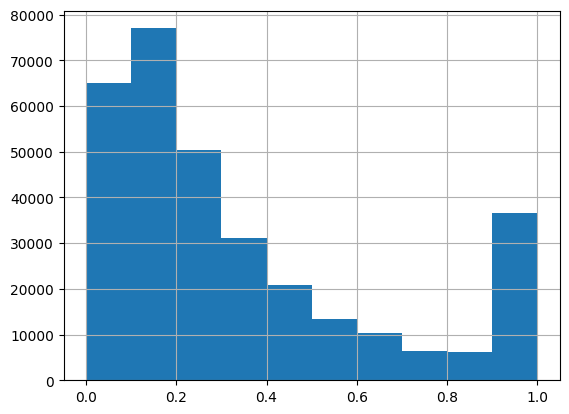

In [4]:
y_train.hist()

In [5]:
X_train

,cat3_slug,land_size,building_size,deed_type,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,...,has_cooling_system_1,has_cooling_system_2,has_restroom_0,building_direction_0,building_direction_1,floor_material_0,floor_material_1,floor_material_2,floor_material_3,category_0
0,0.090909,0.087591,0.108434,1.0,0.161290,0.2,0.071429,0.125,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.727273,1.000000,1.000000,1.0,0.096774,0.2,0.071429,0.125,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,0.090909,0.166199,0.213855,0.4,0.096774,0.4,0.035714,0.250,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.090909,0.491859,0.478916,0.4,0.032258,0.4,0.071429,0.000,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.090909,0.177428,0.177711,1.0,0.129032,0.2,0.071429,0.125,1.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317436,1.000000,0.123526,0.165663,1.0,0.129032,0.0,0.107143,0.125,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
317437,0.181818,0.222347,0.524096,0.6,0.129032,0.6,0.142857,0.125,1.0,1.0,...,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
317438,1.000000,0.446940,0.358434,1.0,0.129032,0.0,0.142857,0.125,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
317439,0.727273,1.000000,1.000000,1.0,0.096774,0.2,0.071429,0.125,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


# Modeling

## Method 1 (LinearRegression)

In [6]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=20)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=2)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.29
mse =	 0.12
mae =	 0.27


In [7]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=20)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=2)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.29
mse =	 0.12
mae =	 0.27


In [8]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=10)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=2)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.27
mse =	 0.12
mae =	 0.26


In [9]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=8)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=2)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.25
mse =	 0.11
mae =	 0.26


In [10]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=8)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=3)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.25
mse =	 0.11
mae =	 0.26


In [11]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=8)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=1)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.23
mse =	 0.11
mae =	 0.26


In [12]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=5)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)
poly_transformer = PolynomialFeatures(degree=1)
X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.2
mse =	 0.11
mae =	 0.26


In [13]:
model = LinearRegression(positive=True)
fs = RFE(model, n_features_to_select=5)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)

model.fit(X_train1, y_train)
y_pred = model.predict(X_valid1)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.2
mse =	 0.11
mae =	 0.26


In [14]:
#PCA
pca = PCA(n_components=10)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=2)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)
y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.14
mse =	 0.1
mae =	 0.25


In [15]:
#PCA
pca = PCA(n_components=20)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=2)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.2
mse =	 0.11
mae =	 0.26


In [16]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=2)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.08
mse =	 0.1
mae =	 0.25


In [17]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=4)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.06
mse =	 0.1
mae =	 0.24


In [18]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

model = LinearRegression(positive=True)
model.fit(X_train1, y_train)

y_pred = model.predict(X_valid1)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.03
mse =	 0.09
mae =	 0.25


In [19]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [20]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=3)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = LinearRegression(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.05
mse =	 0.1
mae =	 0.25


## Method 2 (Ridge)

In [21]:
model = Ridge(positive=True)
fs = RFE(model, n_features_to_select=5)
X_train1 = fs.fit_transform(X_train, y_train)
X_valid1 = fs.transform(X_valid)
X_test1 = fs.transform(X_test)

model.fit(X_train1, y_train)

y_pred = model.predict(X_valid1)
r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.2
mse =	 0.11
mae =	 0.26


In [22]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Ridge(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [23]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Ridge(alpha=0.1, positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [24]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Ridge(alpha=10, positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [25]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=4)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Ridge(positive=True)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.06
mse =	 0.1
mae =	 0.25


In [26]:
y_pred = model.predict(X_test2)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.1
mse =	 0.1
mae =	 0.25


## Method 3 (Lasso)

In [27]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Lasso(alpha=0.1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [28]:
y_pred

array([0.34049172, 0.34049172, 0.34049172, ..., 0.34049172, 0.34049172,
       0.34049172], shape=(29472,))

In [29]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=4)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Lasso(alpha=0.1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [30]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = Lasso(alpha=0.1)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [31]:
model = Lasso(alpha=0.1)
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [32]:
model = Lasso(alpha=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [33]:
model = Lasso(alpha=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_valid)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [34]:
poly_transformer = PolynomialFeatures(degree=2)

X_train1 = poly_transformer.fit_transform(X_train)
X_valid1 = poly_transformer.transform(X_valid)
X_test1 = poly_transformer.transform(X_test)

model = Lasso(alpha=0.1)
model.fit(X_train1, y_train)

y_pred = model.predict(X_valid1)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.0
mse =	 0.09
mae =	 0.24


In [35]:
y_pred

array([0.34049172, 0.34049172, 0.34049172, ..., 0.34049172, 0.34049172,
       0.34049172], shape=(29472,))

## Method 4 (SVR)

In [36]:
#PCA
pca = PCA(n_components=5)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = SVR(C=1.0, max_iter=1000)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -1.46
mse =	 0.22
mae =	 0.42


In [37]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=1)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = SVR(C=1.0, max_iter=1000)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -0.39
mse =	 0.13
mae =	 0.33


In [38]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)


model = SVR(C=1.0, max_iter=1000)
model.fit(X_train1, y_train)

y_pred = model.predict(X_valid1)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -0.28
mse =	 0.12
mae =	 0.31


In [39]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)


model = SVR(C=0.1, max_iter=1000)
model.fit(X_train1, y_train)

y_pred = model.predict(X_valid1)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -0.27
mse =	 0.12
mae =	 0.31


In [40]:
#PCA
pca = PCA(n_components=2)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=3)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = SVR(C=1.0, max_iter=1000)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -0.28
mse =	 0.12
mae =	 0.31


In [41]:
#PCA
pca = PCA(n_components=3)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=3)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = SVR(C=1.0, max_iter=1000)
model.fit(X_train2, y_train)

y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

d:\miniconda3\envs\quera\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


r2 =	 -0.25
mse =	 0.11
mae =	 0.3


## Method 5 (DecisionTreeRegressor)

In [42]:
model = DecisionTreeRegressor()
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [2, 4, 8]
}
grid = GridSearchCV(model, param_grid, scoring='r2', cv=5)
grid.fit(X_train, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [2, 4, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [43]:
model = grid.best_estimator_
y_pred = model.predict(X_valid)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.71
mse =	 0.16
mae =	 0.3


In [44]:
#PCA
pca = PCA(n_components=3)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

model = DecisionTreeRegressor()
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [1, 2, 4, 8]
}
grid = GridSearchCV(model, param_grid, scoring='r2', cv=5)
grid.fit(X_train1, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [45]:
model = grid.best_estimator_
y_pred = model.predict(X_valid1)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.38
mse =	 0.13
mae =	 0.27


In [46]:
#PCA
pca = PCA(n_components=3)
X_train1 = pca.fit_transform(X_train)
X_valid1 = pca.fit_transform(X_valid)
X_test1 = pca.fit_transform(X_test)

poly_transformer = PolynomialFeatures(degree=2)

X_train2 = poly_transformer.fit_transform(X_train1)
X_valid2 = poly_transformer.transform(X_valid1)
X_test2 = poly_transformer.transform(X_test1)

model = DecisionTreeRegressor()
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [2, 4, 8]
}
grid = GridSearchCV(model, param_grid, scoring='r2', cv=5)
grid.fit(X_train2, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [2, 4, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [47]:
model = grid.best_estimator_
y_pred = model.predict(X_valid2)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.38
mse =	 0.13
mae =	 0.27


In [48]:
y_pred = model.predict(X_test2)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

r2 =	 -0.41
mse =	 0.13
mae =	 0.27


## Method 6 (Shallow neural networks)

In [49]:
X_train.shape

(317441, 34)

In [50]:
# #PCA
# pca = PCA(n_components=3)
# X_train1 = pca.fit_transform(X_train)
# X_valid1 = pca.fit_transform(X_valid)
# X_test1 = pca.fit_transform(X_test)

In [ ]:
# define model
model = keras.Sequential()
model.add(keras.layers.Input(X_train.shape[1:]))
model.add(keras.layers.Dense(units=64, activation='relu'))
model.add(keras.layers.Dense(units=32, activation='relu'))
model.add(keras.layers.Dense(units=1))

model.summary()

# compile model
model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=0.001) , metrics=['mse', 'mae', 'r2_score'])

# train model
history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=40,
                    validation_data=(X_valid, y_valid),
                    shuffle=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
9921/9921 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - loss: 0.0487 - mae: 0.1549 - mse: 0.0487 - r2_score: 0.4642 - val_loss: 0.1380 - val_mae: 0.2841 - val_mse: 0.1380 - val_r2_score: -0.5159
Epoch 2/40
9921/9921 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 0.0414 - mae: 0.1401 - mse: 0.0414 - r2_score: 0.5448 - val_loss: 0.1445 - val_mae: 0.2860 - val_mse: 0.1445 - val_r2_score: -0.5882
Epoch 3/40
9921/9921 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 0.0398 - mae: 0.1359 - mse: 0.0398 - r2_score: 0.5619 - val_loss: 0.1415 - val_mae: 0.2832 - val_mse: 0.1415 - val_r2_score: -0.5551
Epoch 4/40
9921/9921 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - loss: 0.0388 - mae: 0.1332 - mse: 0.0388 - r2_score: 0.5734 - val_loss: 0.1489 - val_mae: 0.2934 - val_mse: 0.1489 - val_r2_score: -0.6357
Epoch 5/40
9921/9921 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 0.0381 - mae: 0.1314 - mse: 0.0381 - r2_score: 0.5810 - val_loss: 0.1479 - val_mae: 0.2919 - val_mse: 0.1479 - val_r2_score: -0.6255
Epoch 6/40
9921/9921

In [52]:
y_pred = model.predict(X_valid)

r2 = r2_score(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
mae = mean_absolute_error(y_valid, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

921/921 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step
r2 =	 -0.68
mse =	 0.15
mae =	 0.3


In [53]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("r2 =\t", round(r2, 2))
print("mse =\t", round(mse, 2))
print("mae =\t", round(mae, 2))

412/412 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step
r2 =	 -0.68
mse =	 0.15
mae =	 0.29


In [54]:
y_test

0        0.668883
1        1.000000
2        0.344108
3        0.135323
4        0.436901
           ...   
13167    0.096659
13168    0.146922
13169    0.108259
13170    0.305444
13171    0.305444
Name: full_price, Length: 13172, dtype: float64

In [55]:
y_pred

array([[0.2935129 ],
       [0.6745448 ],
       [0.4299112 ],
       ...,
       [0.57002085],
       [0.13545793],
       [0.5231198 ]], shape=(13172, 1), dtype=float32)